In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
loan_data = pd.read_csv("loan_approval_data.csv")
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
loan_data.shape

(1000, 20)

In [4]:
loan_data.isnull().any()


Applicant_ID          True
Applicant_Income      True
Coapplicant_Income    True
Employment_Status     True
Age                   True
Marital_Status        True
Dependents            True
Credit_Score          True
Existing_Loans        True
DTI_Ratio             True
Savings               True
Collateral_Value      True
Loan_Amount           True
Loan_Term             True
Loan_Purpose          True
Property_Area         True
Education_Level       True
Gender                True
Employer_Category     True
Loan_Approved         True
dtype: bool

In [5]:
print(loan_data.dtypes)

Applicant_ID          float64
Applicant_Income      float64
Coapplicant_Income    float64
Employment_Status      object
Age                   float64
Marital_Status         object
Dependents            float64
Credit_Score          float64
Existing_Loans        float64
DTI_Ratio             float64
Savings               float64
Collateral_Value      float64
Loan_Amount           float64
Loan_Term             float64
Loan_Purpose           object
Property_Area          object
Education_Level        object
Gender                 object
Employer_Category      object
Loan_Approved          object
dtype: object


In [6]:
x=loan_data.drop("Loan_Approved",axis=1)
y=loan_data["Loan_Approved"]

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


num_features = loan_data.select_dtypes(include=["float64"]).columns
cat_features = loan_data.select_dtypes(include=["object"]).columns

num_impute = SimpleImputer(strategy="median")
loan_data[num_features] = num_impute.fit_transform(loan_data[num_features])

cat_impute = SimpleImputer(strategy="most_frequent")
loan_data[cat_features] = cat_impute.fit_transform(loan_data[cat_features])

In [8]:

loan_data.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


Exploratory data anyalysis

Text(0.5, 1.0, 'is loan approved or not')

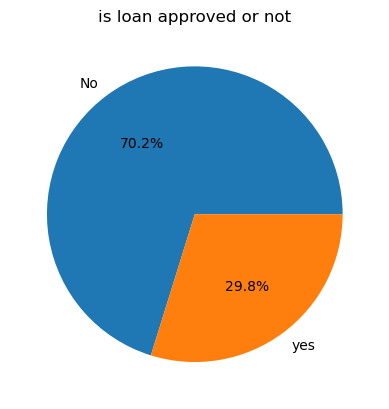

In [11]:
classes_count = loan_data["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No","yes"],autopct ="%1.1f%%")
plt.title("is loan approved or not")


[Text(0, 0, '621'), Text(0, 0, '379')]

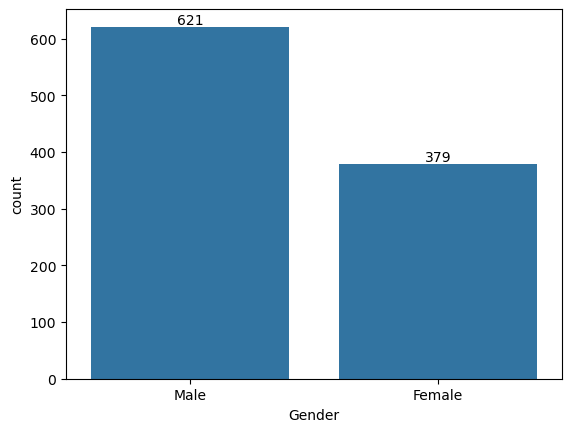

In [15]:
#analyze categories

gender_cnt= loan_data["Gender"].value_counts()
ax =sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

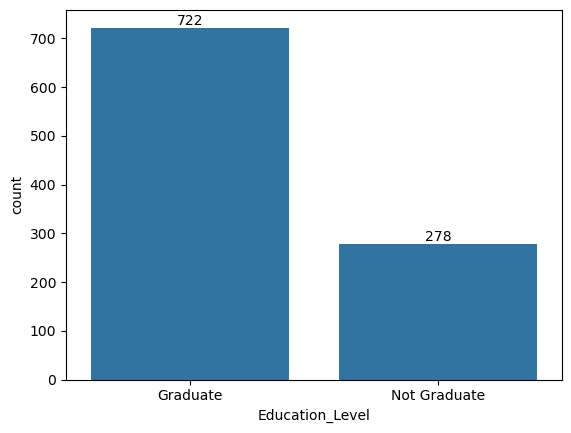

In [16]:
#analyze categories

edu_cnt= loan_data["Education_Level"].value_counts()
ax =sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

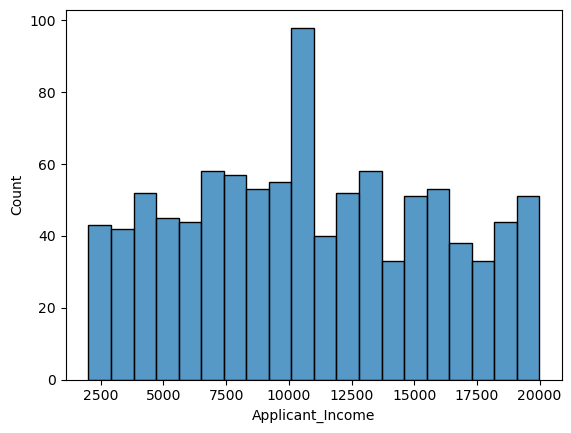

In [17]:
#anyalyze income

sns.histplot(
    data =loan_data,
    x = "Applicant_Income",
    bins =20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

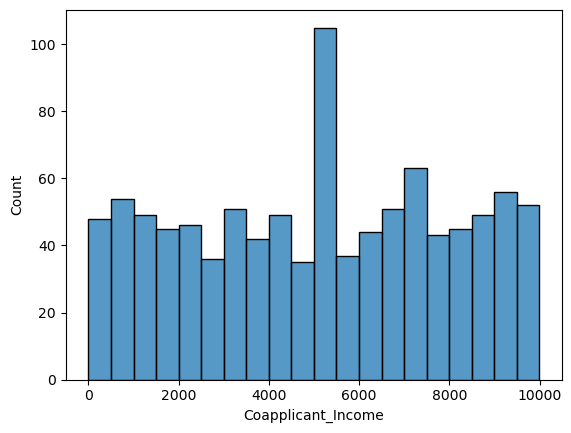

In [18]:
#anyalyze income

sns.histplot(
    data =loan_data,
    x = "Coapplicant_Income",
    bins =20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

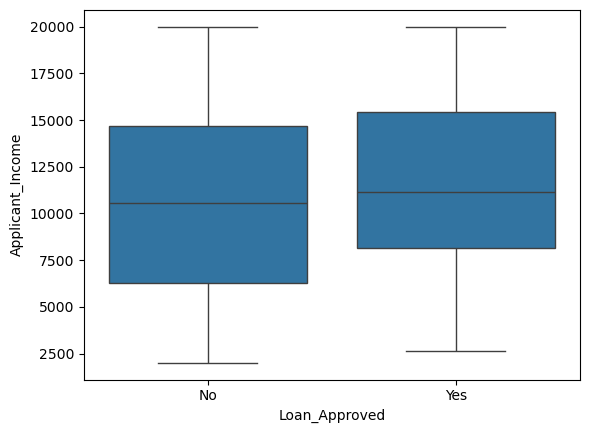

In [19]:
#box plot for outliers

sns.boxplot(
    data =loan_data,
    x="Loan_Approved",
    y= "Applicant_Income")
    

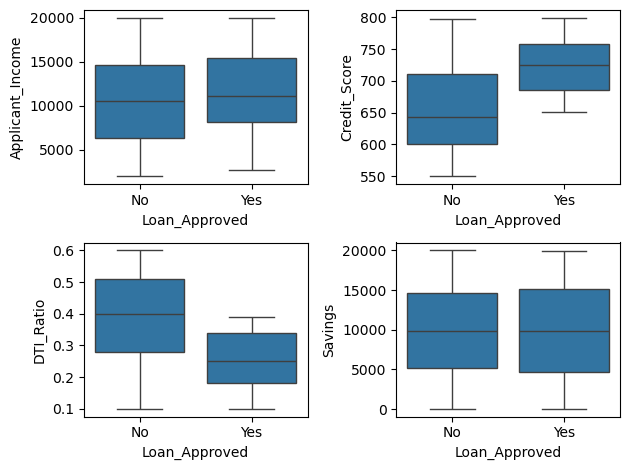

In [22]:
fig,axes = plt.subplots(2,2)
sns.boxplot(
    ax =axes[0,0],
    data =loan_data,
    x="Loan_Approved",
    y= "Applicant_Income")
sns.boxplot(
    ax =axes[0,1],
    data =loan_data,
    x="Loan_Approved",
    y= "Credit_Score")
sns.boxplot(
    ax =axes[1,0],
    data =loan_data,
    x="Loan_Approved",
    y= "DTI_Ratio")
sns.boxplot(
    ax =axes[1,1],
    data =loan_data,
    x="Loan_Approved",
    y= "Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

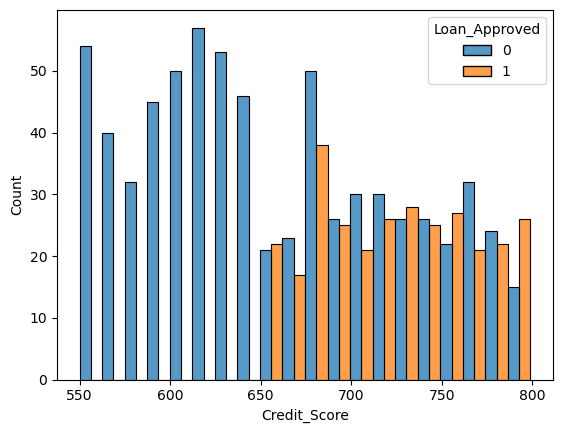

In [27]:
#credit score with loan approved
sns.histplot(
    data = loan_data,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple ="dodge")
    

In [28]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
loan_data["Education_Level"]= le.fit_transform(loan_data["Education_Level"])
loan_data["Loan_Approved"]= le.fit_transform(loan_data["Loan_Approved"])


In [29]:
cols =["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoder = ohe.fit_transform(loan_data[cols])
encoded_df = pd.DataFrame(encoder, columns=ohe.get_feature_names_out(cols), index =loan_data.index)
loan_data = pd.concat([loan_data.drop(columns= cols),encoded_df],axis=1)

In [30]:
loan_data = loan_data.drop("Applicant_ID",axis=1)

In [31]:
loan_data.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


Correlation Heatmap

<Axes: >

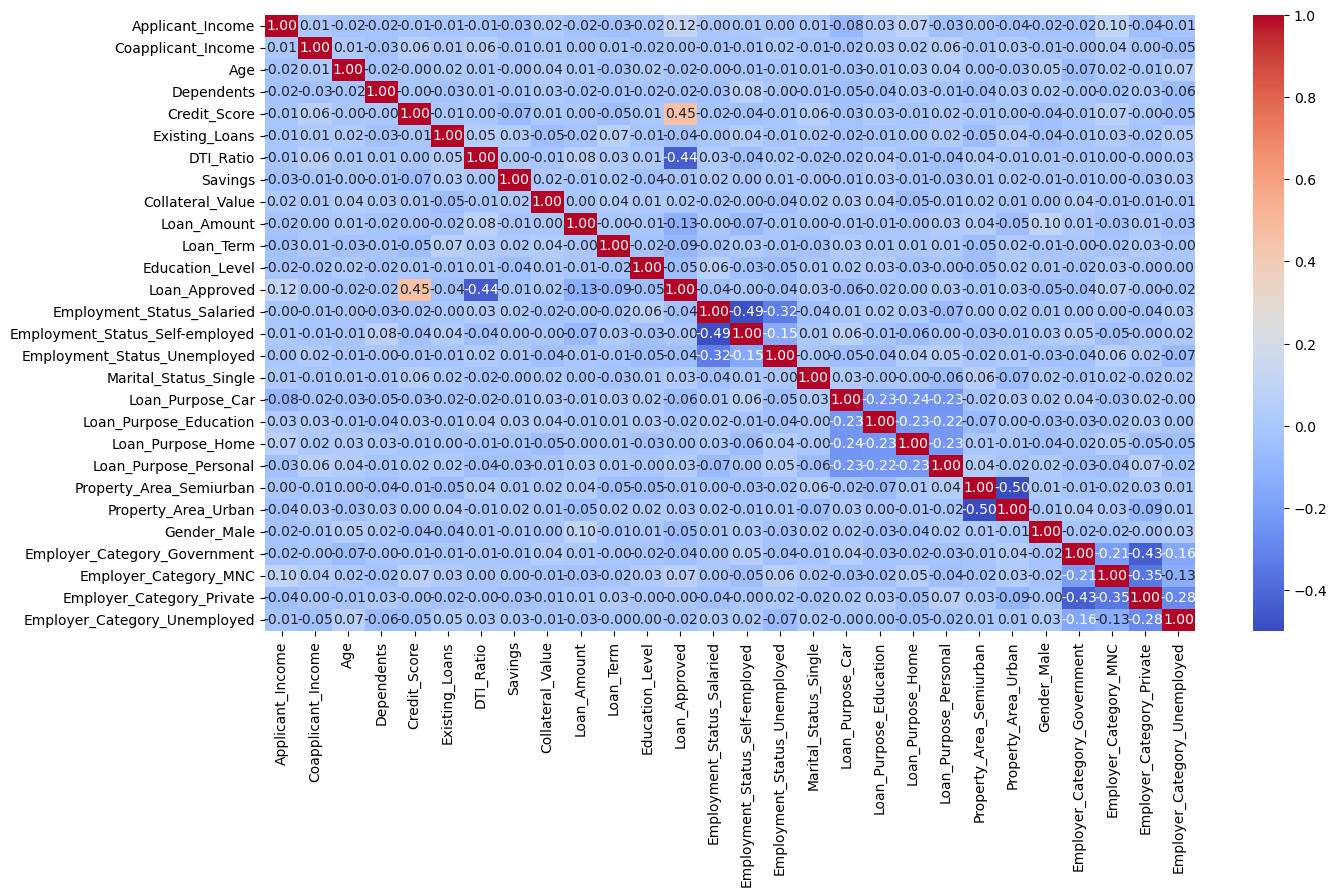

In [39]:
num_cols = loan_data.select_dtypes(include = "number")
corr_matrix = num_cols.corr()
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot =True,
    fmt =".2f",
    cmap ="coolwarm")

In [36]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)


Loan_Approved                      1.000000
Credit_Score                       0.451235
Applicant_Income                   0.120177
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021709
Coapplicant_Income                 0.003957
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013462
Loan_Purpose_Education            -0.016684
Dependents                        -0.018999
Employer_Category_Unemployed      -0.021468
Age                               -0.022354
Existing_Loans                    -0.035101
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

Train_test-split and feature scaling

In [40]:
x=loan_data.drop("Loan_Approved",axis =1)
y = loan_data["Loan_Approved"]

In [41]:
x.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [42]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state =42) 

In [43]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Train And Evaluate models

In [46]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,confusion_matrix,accuracy_score,recall_score,f1_score


log_model = LogisticRegression()
log_model.fit(x_train_scaled,y_train)

y_pred = log_model.predict(x_test_scaled)

#evaluation
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("confusion matrix:",confusion_matrix(y_test,y_pred))

precision: 0.7833333333333333
recall: 0.7704918032786885
accuracy: 0.865
f1: 0.7768595041322314
confusion matrix: [[126  13]
 [ 14  47]]


In [47]:
#knn classifier
from sklearn.neighbors import KNeighborsClassifier
k_model = KNeighborsClassifier()
k_model.fit(x_train_scaled,y_train)

y_pred = k_model.predict(x_test_scaled)

#evaluation
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("confusion matrix:",confusion_matrix(y_test,y_pred))

precision: 0.62
recall: 0.5081967213114754
accuracy: 0.755
f1: 0.5585585585585585
confusion matrix: [[120  19]
 [ 30  31]]


In [48]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
n_model = GaussianNB()
n_model.fit(x_train_scaled,y_train)

y_pred = n_model.predict(x_test_scaled)

#evaluation
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("confusion matrix:",confusion_matrix(y_test,y_pred))

precision: 0.8035714285714286
recall: 0.7377049180327869
accuracy: 0.865
f1: 0.7692307692307693
confusion matrix: [[128  11]
 [ 16  45]]
